# THUẬT TOÁN 2 (TT2): PHÂN ĐOẠN TIẾNG NÓI / KHOẢNG LẶNG (VAD)
## ADAPTIVE HISTOGRAM THRESHOLDING (ENERGY & SPECTRAL CENTROID - GIANNAKOPOULOS 2014)

### 1. Cấu hình môi trường và tham số hệ thống
Khai báo thư viện (`numpy`, `matplotlib`, `wave`), nạp `IPython.display.Audio`, định vị thư mục dự án và thiết lập tham số framing.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import wave

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import Audio, display

def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "TinHieuHuanLuyen").exists() and (candidate / "TinHieuKiemThu").exists():
            return candidate
    return Path.cwd()

PROJECT_ROOT = find_project_root()
TRAIN_DIR = PROJECT_ROOT / "TinHieuHuanLuyen"
TEST_DIR = PROJECT_ROOT / "TinHieuKiemThu"
OUTPUT_DIR = PROJECT_ROOT / "src" / "TT2" / "output" / "mine"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Tham số DSP chuẩn hóa
FRAME_MS = 25         # Độ dài khung (ms)
HOP_MS = 10           # Bước trượt khung (ms)
MIN_SILENCE_MS = 200  # Ngưỡng lấp khoảng lặng ảo (ms)

# Đệm biên (padding) theo khung (1 khung = HOP_MS = 10 ms)
PAD_START = 1
PAD_END = 1

### 2. Cấu trúc dữ liệu mẫu âm thanh (Sample)
Lớp dữ liệu lưu trữ tín hiệu âm thanh, tần số lấy mẫu, các chuỗi đặc trưng chuẩn hóa và nhãn chuẩn Ground Truth.

In [2]:
@dataclass
class Sample:
    """Một tệp âm thanh cùng với đặc trưng STE, SC và nhãn Ground-Truth."""
    name: str
    signal: np.ndarray
    fs: int
    ste: np.ndarray            # Năng lượng ngắn hạn (STE) chuẩn hóa [0, 1]
    sc: np.ndarray             # Trọng tâm phổ (Spectral Centroid) chuẩn hóa [0, 1]
    frame_starts: np.ndarray   # Mốc thời gian bắt đầu từng khung (s)
    gt: tuple                  # Biên chuẩn (start, end) theo giây

    @property
    def duration(self):
        return len(self.signal) / self.fs

### 3. Đọc dữ liệu sóng âm WAV (PCM 16-bit)
Đọc tín hiệu âm thanh, chuẩn hóa biên độ về đoạn `[-1, 1]` và lấy tần số lấy mẫu `fs`.

In [3]:
def read_wav(wav_path):
    """Đọc file WAV 16-bit PCM, chuẩn hóa biên độ về [-1, 1] và trả về fs."""
    with wave.open(str(wav_path), "rb") as wf:
        fs = wf.getframerate()
        raw = wf.readframes(wf.getnframes())
    signal = np.frombuffer(raw, dtype=np.int16).astype(float)
    return signal / max(np.max(np.abs(signal)), 1.0), fs

### 4. Đọc nhãn phân đoạn Praat .lab (Ground-Truth)
Trích xuất mốc bắt đầu và kết thúc chuẩn bao trùm toàn bộ các âm hữu thanh (`v`) và vô thanh (`uv`).

In [4]:
def read_speech_bounds(lab_path):
    """Đọc file nhãn .lab, trả về biên chuẩn (start, end) tính theo giây."""
    segments = []
    for line in lab_path.read_text(encoding="utf-8").splitlines():
        parts = line.split()
        if len(parts) == 3 and parts[2].lower() in {"v", "uv"}:
            segments.append((float(parts[0]), float(parts[1])))
    return round(min(s for s, _ in segments), 4), round(max(e for _, e in segments), 4)

### 5. Trích xuất đặc trưng STE và Spectral Centroid (SC)
Tính toán 2 đặc trưng phân khung theo nghiên cứu của Giannakopoulos (2014) và chuẩn hóa về miền `[0, 1]`.

In [5]:
def compute_features(signal, fs, frame_ms=FRAME_MS, hop_ms=HOP_MS):
    """Trích xuất Short-Time Energy (STE) và Spectral Centroid (SC) chuẩn hóa [0, 1]."""
    frame_size = int(round(frame_ms * fs / 1000.0))
    hop_size = int(round(hop_ms * fs / 1000.0))
    n_frames = max(1, int(np.ceil(max(0, len(signal) - frame_size) / hop_size)) + 1)

    bin_index = np.arange(1, frame_size // 2 + 2)
    n_bins = len(bin_index)

    ste = np.zeros(n_frames)
    sc = np.zeros(n_frames)
    frame_starts = np.arange(n_frames) * hop_size / fs

    for i in range(n_frames):
        chunk = signal[i * hop_size : i * hop_size + frame_size]
        frame = np.zeros(frame_size)
        frame[:len(chunk)] = chunk

        ste[i] = np.mean(frame ** 2)

        magnitude = np.abs(np.fft.rfft(frame))
        total = magnitude.sum()
        if total > 1e-12:
            sc[i] = np.sum(bin_index * magnitude) / (total * n_bins)

    return ste / max(ste.max(), 1e-12), sc / max(sc.max(), 1e-12), frame_starts

### 6. Nạp tập dữ liệu huấn luyện và kiểm thử
Quét các file âm thanh và nhãn ground-truth trong `TinHieuHuanLuyen` và `TinHieuKiemThu`.

In [6]:
def load_dataset(data_dir):
    """Nạp các file .wav và .lab tương ứng, trích xuất đặc trưng trước cho toàn bộ tập."""
    samples = []
    for wav_path in sorted(data_dir.glob("*.wav")):
        signal, fs = read_wav(wav_path)
        ste, sc, frame_starts = compute_features(signal, fs)
        gt = read_speech_bounds(wav_path.with_suffix(".lab"))
        samples.append(Sample(wav_path.name, signal, fs, ste, sc, frame_starts, gt))
    return samples

train_set = load_dataset(TRAIN_DIR)
test_set = load_dataset(TEST_DIR)
print(f"Loaded {len(train_set)} train files and {len(test_set)} test files")

Loaded 4 train files and 4 test files


### 7. Cấu trúc kết quả và ngưỡng thích nghi Histogram
Lưu trữ ngưỡng thích nghi $T$, các cực đại cục bộ $M_1, M_2$ và quyết định nhị phân từng khung.

In [7]:
@dataclass
class HistogramThreshold:
    """Ngưỡng thích nghi của một đặc trưng cùng dữ liệu biểu đồ tần suất."""
    value: float          # T = (W * M1 + M2) / (W + 1)
    m1: float             # Cực đại cục bộ 1 (silence peak)
    m2: float             # Cực đại cục bộ 2 (speech peak)
    centers: np.ndarray   # Tọa độ tâm các bin
    smooth: np.ndarray    # Mảng tần suất sau khi làm mịn

@dataclass
class VADResult:
    start: float            # Mốc bắt đầu tiếng nói dự đoán (s)
    end: float              # Mốc kết thúc tiếng nói dự đoán (s)
    labels: np.ndarray      # Quyết định từng khung: 1 = tiếng nói, 0 = khoảng lặng
    energy: HistogramThreshold
    centroid: HistogramThreshold

### 8. Lớp mô hình VAD Histogram thích ứng 2 đặc trưng (Giannakopoulos 2014)
Tìm ngưỡng thích nghi từ biểu đồ tần suất cho STE và SC, kết hợp logic AND và hậu xử lý lọc khoảng lặng ảo.

In [8]:
class HistogramVAD:
    """Bộ phát hiện tiếng nói thích nghi ngưỡng dựa trên biểu đồ tần suất của STE và SC."""

    def __init__(self, bins=100, smoothing_width=5, weight_e=5.0, weight_c=5.0,
                 pad_start=PAD_START, pad_end=PAD_END):
        self.bins = bins
        self.smoothing_width = smoothing_width
        self.weight_e = weight_e
        self.weight_c = weight_c
        self.pad_start = pad_start
        self.pad_end = pad_end

    def _smooth(self, counts):
        """Làm mịn biểu đồ tần suất bằng cửa sổ trượt trung bình động."""
        half = self.smoothing_width // 2
        return np.array([counts[max(0, i - half): i + half + 1].mean() for i in range(len(counts))])

    @staticmethod
    def _first_two_peaks(smooth):
        """Tìm 2 đỉnh cực đại cục bộ đầu tiên M1, M2 trên biểu đồ tần suất đã làm mịn."""
        peaks = []
        if smooth[0] >= smooth[1]:
            peaks.append(0)
        peaks += [i for i in range(1, len(smooth) - 1)
                  if smooth[i] > smooth[i - 1] and smooth[i] >= smooth[i + 1]]
        if len(peaks) >= 2:
            return peaks[0], peaks[1]

        first = int(np.argmax(smooth))
        candidates = [i for i in range(len(smooth)) if abs(i - first) > 2]
        second = max(candidates, key=lambda i: smooth[i]) if candidates else min(first + 3, len(smooth) - 1)
        return tuple(sorted((first, second)))

    def estimate_threshold(self, values, weight):
        """Xây dựng histogram làm mịn, tìm M1, M2 và tính ngưỡng phân biệt T."""
        counts, edges = np.histogram(values, bins=self.bins, range=(float(values.min()), float(values.max())))
        centers = (edges[:-1] + edges[1:]) / 2.0
        smooth = self._smooth(counts)
        i1, i2 = self._first_two_peaks(smooth)
        m1, m2 = float(centers[i1]), float(centers[i2])
        return HistogramThreshold((weight * m1 + m2) / (weight + 1.0), m1, m2, centers, smooth)

    @staticmethod
    def _fill_short_silences(labels, first, last, min_frames):
        """Lấp đầy khoảng lặng ảo ngắn < 200 ms nằm giữa vùng tiếng nói."""
        idx = first
        while idx <= last:
            if labels[idx] == 1:
                idx += 1
                continue
            gap_start = idx
            while idx <= last and labels[idx] == 0:
                idx += 1
            if idx - gap_start < min_frames:
                labels[gap_start:idx] = 1

    def predict(self, sample):
        """Thực hiện phân đoạn VAD trên một mẫu âm thanh."""
        energy = self.estimate_threshold(sample.ste, self.weight_e)
        centroid = self.estimate_threshold(sample.sc, self.weight_c)
        labels = ((sample.ste >= energy.value) & (sample.sc >= centroid.value)).astype(int)

        speech = np.flatnonzero(labels)
        if len(speech) == 0:
            return VADResult(0.0, 0.0, labels, energy, centroid)
        first, last = int(speech[0]), int(speech[-1])

        self._fill_short_silences(labels, first, last, int(round(MIN_SILENCE_MS / HOP_MS)))

        start_idx = max(0, first - self.pad_start)
        end_idx = min(len(labels) - 1, last + self.pad_end)
        labels[start_idx:first] = 1
        labels[last + 1:end_idx + 1] = 1

        start = float(sample.frame_starts[start_idx])
        end = min(sample.duration, float(sample.frame_starts[end_idx]) + FRAME_MS / 1000.0)
        return VADResult(round(start, 4), round(end, 4), labels, energy, centroid)

### 9. Cấu trúc đánh giá và các hàm đo lường sai số (MAE, RMSE)
Tính sai số lệch mốc đầu $\Delta Start$, mốc đuôi $\Delta End$, MAE và RMSE (ms).

In [9]:
@dataclass
class Evaluation:
    """Kết quả dự đoán kèm sai số biên (ms) so với Ground Truth."""
    sample: Sample
    result: VADResult
    d_start: float
    d_end: float

    @property
    def mae(self):
        return (abs(self.d_start) + abs(self.d_end)) / 2.0

    @property
    def rmse(self):
        return float(np.sqrt((self.d_start ** 2 + self.d_end ** 2) / 2.0))

def evaluate(samples, vad):
    """Chạy mô hình VAD trên tập mẫu và tính toán sai số phân đoạn."""
    evaluations = []
    for sample in samples:
        result = vad.predict(sample)
        d_start = (result.start - sample.gt[0]) * 1000.0
        d_end = (result.end - sample.gt[1]) * 1000.0
        evaluations.append(Evaluation(sample, result, d_start, d_end))
    return evaluations

def mean_mae(evaluations):
    return float(np.mean([e.mae for e in evaluations]))

def mean_rmse(evaluations):
    return float(np.mean([e.rmse for e in evaluations]))

def print_report(title, evaluations):
    """In bảng tổng kết kết quả đánh giá phân đoạn chi tiết theo từng file."""
    header = (f"{'File':<16} | {'T_E (STE)':<10} | {'T_C (SC)':<10} | {'Ground truth':<16} | {'Predicted':<16} | "
              f"{'ΔStart':<9} | {'ΔEnd':<9} | {'MAE (ms)':<9} | {'RMSE (ms)':<9}")
    width = len(header)
    print("=" * width)
    print(f"{title:^{width}}")
    print("=" * width)
    print(header)
    print("-" * width)
    for e in evaluations:
        gt = f"[{e.sample.gt[0]:.2f}, {e.sample.gt[1]:.2f}]"
        pred = f"[{e.result.start:.2f}, {e.result.end:.2f}]"
        print(f"{e.sample.name:<16} | {e.result.energy.value:<10.4f} | {e.result.centroid.value:<10.4f} | "
              f"{gt:<16} | {pred:<16} | {e.d_start:+7.1f}ms | {e.d_end:+7.1f}ms | {e.mae:9.2f} | {e.rmse:9.2f}")
    print("-" * width)
    print(f"Mean MAE = {mean_mae(evaluations):.2f} ms  |  Mean RMSE = {mean_rmse(evaluations):.2f} ms")
    print("=" * width)

### 10. Đánh giá mô hình trên tập Huấn luyện (Train Set Evaluation)
Chạy thuật toán trên 4 file huấn luyện để kiểm chứng ngưỡng thích nghi và độ chính xác phân đoạn ban đầu.

In [10]:
vad = HistogramVAD()
train_eval = evaluate(train_set, vad)
print_report("TRAIN SET EVALUATION", train_eval)

                                                      TRAIN SET EVALUATION                                                      
File             | T_E (STE)  | T_C (SC)   | Ground truth     | Predicted        | ΔStart    | ΔEnd      | MAE (ms)  | RMSE (ms)
--------------------------------------------------------------------------------------------------------------------------------
phone_F1.wav     | 0.0153     | 0.1540     | [0.53, 2.75]     | [0.53, 2.75]     |    +0.0ms |    +5.0ms |      2.50 |      3.54
phone_M1.wav     | 0.0220     | 0.1814     | [0.46, 3.52]     | [0.47, 3.54]     |   +10.0ms |   +15.0ms |     12.50 |     12.75
studio_F1.wav    | 0.0150     | 0.2084     | [0.68, 2.15]     | [0.66, 2.15]     |   -20.0ms |    +5.0ms |     12.50 |     14.58
studio_M1.wav    | 0.0150     | 0.2115     | [0.87, 2.06]     | [0.90, 2.06]     |   +30.0ms |    -5.0ms |     17.50 |     21.51
-------------------------------------------------------------------------------------------------

### 11. Đánh giá tổng quan trên tập Kiểm thử (Test Set Evaluation)
Chạy mô hình trên tập kiểm thử độc lập (04 file) và lưu trữ kết quả để trực quan hóa từng file.

In [11]:
test_eval = evaluate(test_set, vad)
print_report("TEST SET EVALUATION", test_eval)
test_eval_dict = {e.sample.name: e for e in test_eval}

                                                      TEST SET EVALUATION                                                       
File             | T_E (STE)  | T_C (SC)   | Ground truth     | Predicted        | ΔStart    | ΔEnd      | MAE (ms)  | RMSE (ms)
--------------------------------------------------------------------------------------------------------------------------------
phone_F2.wav     | 0.0167     | 0.1754     | [1.02, 4.04]     | [1.04, 4.03]     |   +20.0ms |   -15.0ms |     17.50 |     17.68
phone_M2.wav     | 0.0333     | 0.1918     | [0.53, 2.52]     | [0.55, 2.52]     |   +20.0ms |    +5.0ms |     12.50 |     14.58
studio_F2.wav    | 0.0150     | 0.0200     | [0.77, 2.37]     | [0.75, 2.35]     |   -20.0ms |   -15.0ms |     17.50 |     17.68
studio_M2.wav    | 0.0167     | 0.1618     | [0.45, 1.93]     | [0.45, 1.93]     |    +0.0ms |    -5.0ms |      2.50 |      3.54
-------------------------------------------------------------------------------------------------

### 12. Cấu hình trực quan hóa và hàm hiển thị đồ thị + Audio Player
Vẽ 3 phần: (1) Waveform + STE, (2) Spectral Centroid, (3) Histogram 2 đặc trưng; nhúng 2 Audio Players trực tiếp.

In [12]:
C_WAVE = "#4a5568"
C_STE = "#1f77b4"
C_SC = "#ff7f0e"
C_GT = "#d62728"
C_PRED = "#2ca02c"
C_SPEECH = "#2ca02c"

def draw_boundaries(ax, gt, pred):
    for t in gt:
        ax.axvline(t, color=C_GT, linestyle="--", linewidth=1.6)
    for t in pred:
        ax.axvline(t, color=C_PRED, linestyle="-", linewidth=1.6, alpha=0.9)

def label_threshold(ax, x, y, text, color):
    ax.text(x, y, text, color=color, va="bottom", ha="right", fontsize=8.5,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.0))

def draw_histogram(ax, thr, color, title, xlabel, log_scale=False):
    y = np.maximum(thr.smooth, 0.1) if log_scale else thr.smooth
    base = 0.1 if log_scale else 0
    ax.plot(thr.centers, y, color=color, linewidth=1.6)
    ax.fill_between(thr.centers, base, y, where=thr.centers >= thr.value, color=color, alpha=0.18)
    ax.axvline(thr.m1, color="#7f7f7f", linestyle=":", linewidth=1.6, label=f"M1 = {thr.m1:.3f}")
    ax.axvline(thr.m2, color="#9467bd", linestyle=":", linewidth=1.6, label=f"M2 = {thr.m2:.3f}")
    ax.axvline(thr.value, color="black", linestyle="--", linewidth=1.5, label=f"T = {thr.value:.3f}")
    if log_scale:
        ax.set_yscale("log")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frame count (smoothed)" + (", log scale" if log_scale else ""))
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right", fontsize=8, framealpha=0.9)

def plot_and_play_evaluation(ev):
    sample, result = ev.sample, ev.result
    pred = (result.start, result.end)
    t_wave = np.arange(len(sample.signal)) / sample.fs
    t_frame = sample.frame_starts + FRAME_MS / 2000.0
    is_speech = result.labels == 1
    x_max = max(t_wave[-1], t_frame[-1])

    fig = plt.figure(figsize=(14, 10))
    left, right = 0.105, 0.935
    gs_top = fig.add_gridspec(2, 1, left=left, right=right, top=0.835, bottom=0.38, hspace=0.12,
                              height_ratios=[3.0, 1.8])
    gs_bot = fig.add_gridspec(1, 2, left=left, right=right, top=0.27, bottom=0.07, wspace=0.28)

    # (1) Waveform + STE
    ax1 = fig.add_subplot(gs_top[0])
    ax1.plot(t_wave, sample.signal, color=C_WAVE, linewidth=0.5)
    ax1.fill_between(t_frame, -1.05, 1.05, where=is_speech, step="mid", color=C_SPEECH, alpha=0.12)
    draw_boundaries(ax1, sample.gt, pred)
    ax1.set_ylim(-1.05, 1.05)
    ax1.set_ylabel("Amplitude")
    ax1.grid(alpha=0.25)
    ax1b = ax1.twinx()
    ax1b.plot(t_frame, sample.ste, color=C_STE, linewidth=1.3)
    ax1b.axhline(result.energy.value, color=C_STE, linestyle=":", linewidth=1.6)
    ax1b.set_ylim(0, 1.05)
    ax1b.set_ylabel("STE / max(STE)", color=C_STE)
    ax1b.tick_params(axis="y", colors=C_STE)
    label_threshold(ax1b, x_max * 0.995, result.energy.value, f"T_E = {result.energy.value:.3f}", C_STE)

    # (2) Spectral centroid
    ax2 = fig.add_subplot(gs_top[1], sharex=ax1)
    ax2.plot(t_frame, sample.sc, color=C_SC, linewidth=1.3)
    ax2.axhline(result.centroid.value, color=C_SC, linestyle=":", linewidth=1.6)
    ax2.fill_between(t_frame, 0, 1.05, where=is_speech, step="mid", color=C_SPEECH, alpha=0.12)
    draw_boundaries(ax2, sample.gt, pred)
    ax2.set_ylim(0, 1.05)
    ax2.set_ylabel("SC / max(SC)", color=C_SC)
    ax2.tick_params(axis="y", colors=C_SC)
    label_threshold(ax2, x_max * 0.995, result.centroid.value, f"T_C = {result.centroid.value:.3f}", C_SC)
    ax2.set_xlabel("Time (s)")
    ax2.set_xlim(0, x_max)
    ax2.grid(alpha=0.25)
    plt.setp(ax1.get_xticklabels(), visible=False)

    # (3) Histograms of both features
    draw_histogram(fig.add_subplot(gs_bot[0]), result.energy, C_STE,
                   "STE histogram: finding M1, M2 and threshold T_E", "STE / max(STE)", log_scale=True)
    draw_histogram(fig.add_subplot(gs_bot[1]), result.centroid, C_SC,
                   "Spectral Centroid histogram: finding M1, M2 and threshold T_C", "SC / max(SC)")

    # Title and shared legend
    fig.suptitle(sample.name, fontsize=14, fontweight="bold", y=0.985)
    fig.text(0.5, 0.945,
             f"MAE = {ev.mae:.1f} ms  ·  RMSE = {ev.rmse:.1f} ms  ·  ΔStart = {ev.d_start:+.0f} ms  ·  ΔEnd = {ev.d_end:+.0f} ms"
             f"      |      Frame {FRAME_MS} ms  ·  Hop {HOP_MS} ms  ·  Min silence ≥ {MIN_SILENCE_MS} ms",
             ha="center", fontsize=9.5, color="0.25")
    handles = [
        Line2D([0], [0], color=C_WAVE, linewidth=1.2, label="Waveform"),
        Line2D([0], [0], color=C_STE, linewidth=1.6, label="Normalized STE"),
        Line2D([0], [0], color=C_SC, linewidth=1.6, label="Normalized SC"),
        Line2D([0], [0], color="0.3", linestyle=":", linewidth=1.6, label="Adaptive threshold"),
        Line2D([0], [0], color=C_GT, linestyle="--", linewidth=1.6, label="Ground truth (LAB)"),
        Line2D([0], [0], color=C_PRED, linewidth=1.6, label="Predicted boundary"),
        Patch(facecolor=C_SPEECH, alpha=0.3, label="Predicted speech region"),
    ]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.925), ncol=7, fontsize=8.5, frameon=False)

    fig_path = OUTPUT_DIR / f"{Path(sample.name).stem}.png"
    fig.savefig(fig_path, dpi=150)
    print(f"Saved figure: {fig_path}")
    plt.show()

    # Nạp và hiển thị audio player cho file kiểm thử cục bộ
    wav_file_path = TEST_DIR / sample.name
    print(f"🎵 Original Audio ({sample.name}):")
    if wav_file_path.exists():
        display(Audio(filename=str(wav_file_path)))
    else:
        display(Audio(data=sample.signal, rate=sample.fs))

    # Audio player cho đoạn tiếng nói đã phân tách
    st_idx = int(result.start * sample.fs)
    en_idx = min(len(sample.signal), int(result.end * sample.fs))
    if en_idx > st_idx:
        print(f"🔊 Predicted Speech Segment [{result.start:.2f}s - {result.end:.2f}s]:")
        display(Audio(data=sample.signal[st_idx:en_idx], rate=sample.fs))

### 13. Thực nghiệm kiểm thử 1: `phone_F2.wav`
Kênh điện thoại, giọng nữ. Đồ thị Waveform, STE, SC, Histograms và Audio Players.

Saved figure: /home/bim/Projects/DSP_MidTerm/src/TT2/output/mine/phone_F2.png


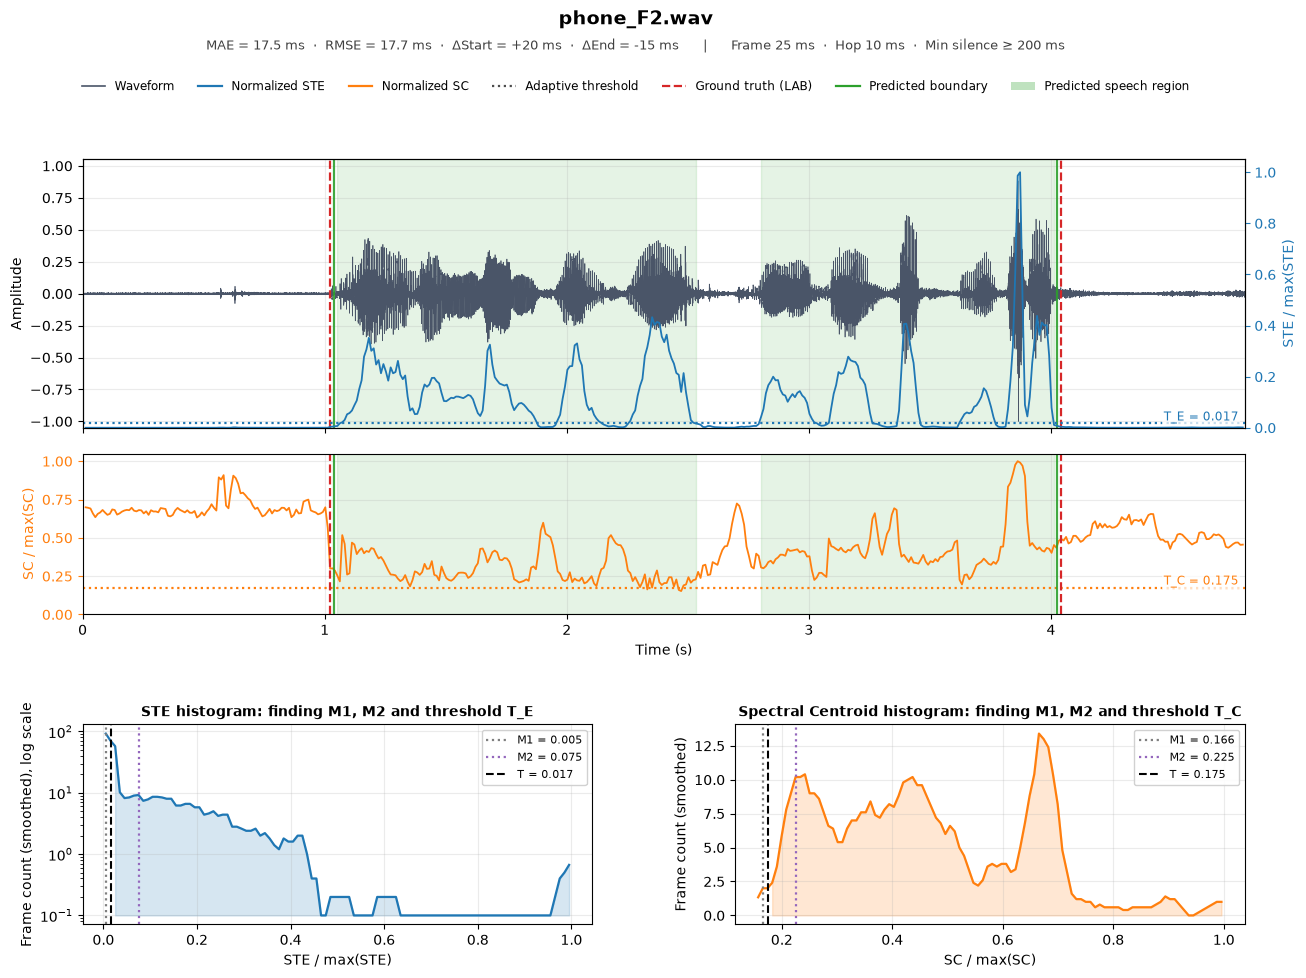

🎵 Original Audio (phone_F2.wav):


🔊 Predicted Speech Segment [1.04s - 4.03s]:


In [13]:
plot_and_play_evaluation(test_eval_dict["phone_F2.wav"])

### 14. Thực nghiệm kiểm thử 2: `phone_M2.wav`
Kênh điện thoại, giọng nam. Đồ thị Waveform, STE, SC, Histograms và Audio Players.

Saved figure: /home/bim/Projects/DSP_MidTerm/src/TT2/output/mine/phone_M2.png


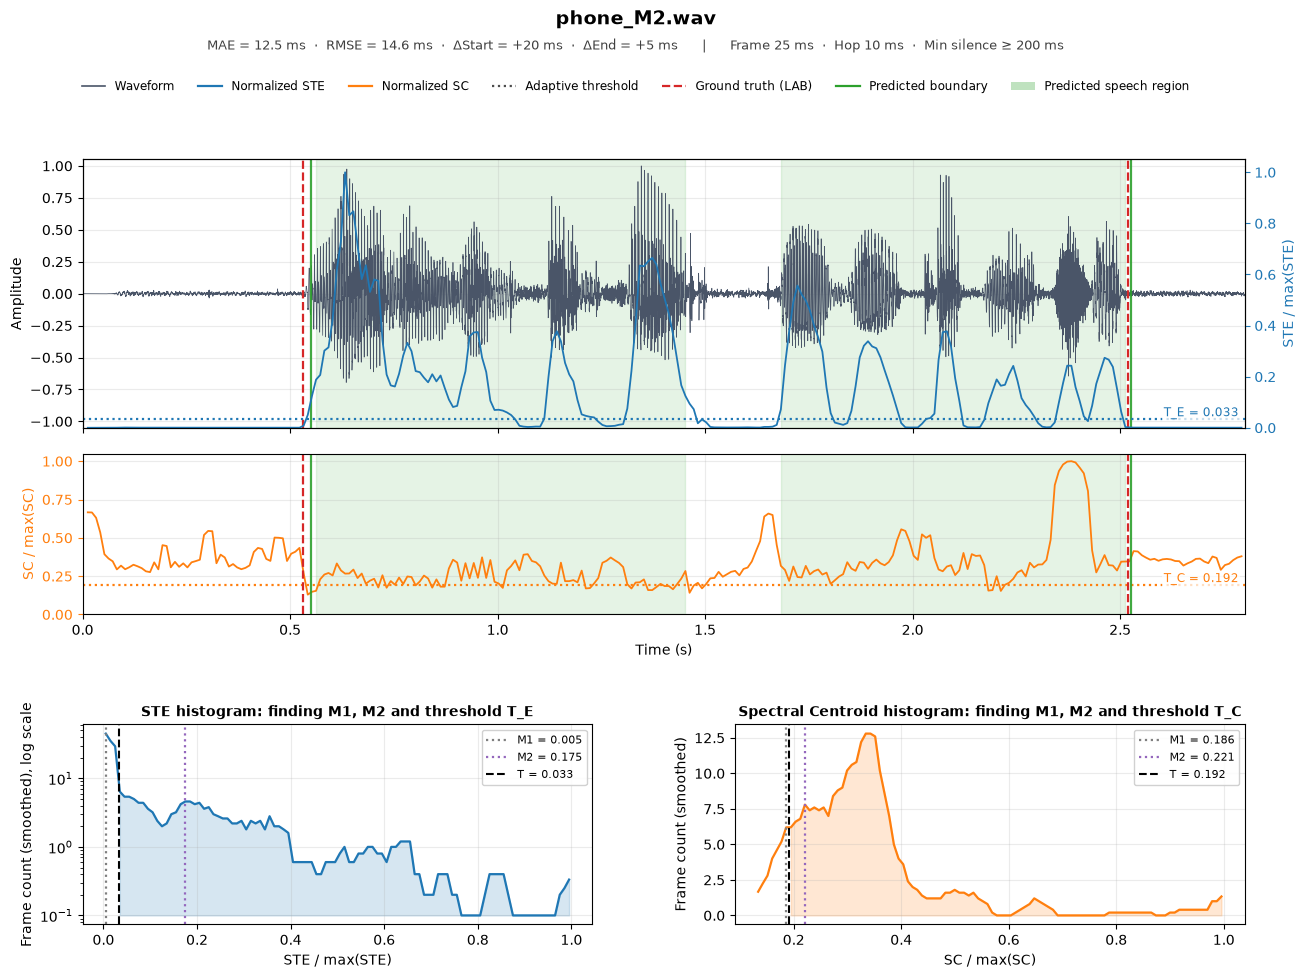

🎵 Original Audio (phone_M2.wav):


🔊 Predicted Speech Segment [0.55s - 2.52s]:


In [14]:
plot_and_play_evaluation(test_eval_dict["phone_M2.wav"])

### 15. Thực nghiệm kiểm thử 3: `studio_F2.wav`
Môi trường phòng thu Studio SNR cao, giọng nữ. Đồ thị Waveform, STE, SC, Histograms và Audio Players.

Saved figure: /home/bim/Projects/DSP_MidTerm/src/TT2/output/mine/studio_F2.png


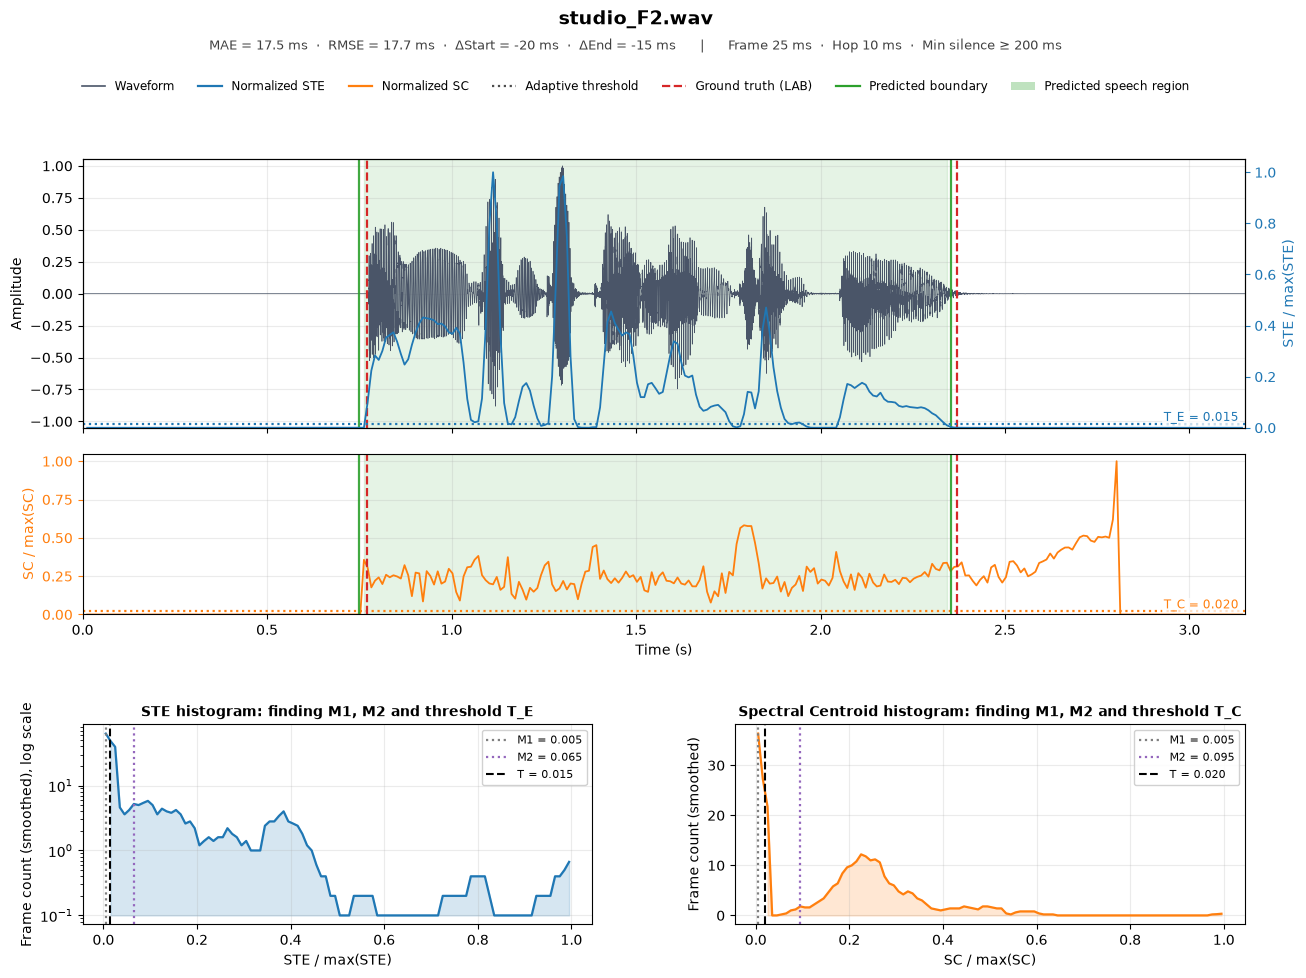

🎵 Original Audio (studio_F2.wav):


🔊 Predicted Speech Segment [0.75s - 2.35s]:


In [15]:
plot_and_play_evaluation(test_eval_dict["studio_F2.wav"])

### 16. Thực nghiệm kiểm thử 4: `studio_M2.wav`
Môi trường phòng thu Studio SNR cao, giọng nam. Đồ thị Waveform, STE, SC, Histograms và Audio Players.

Saved figure: /home/bim/Projects/DSP_MidTerm/src/TT2/output/mine/studio_M2.png


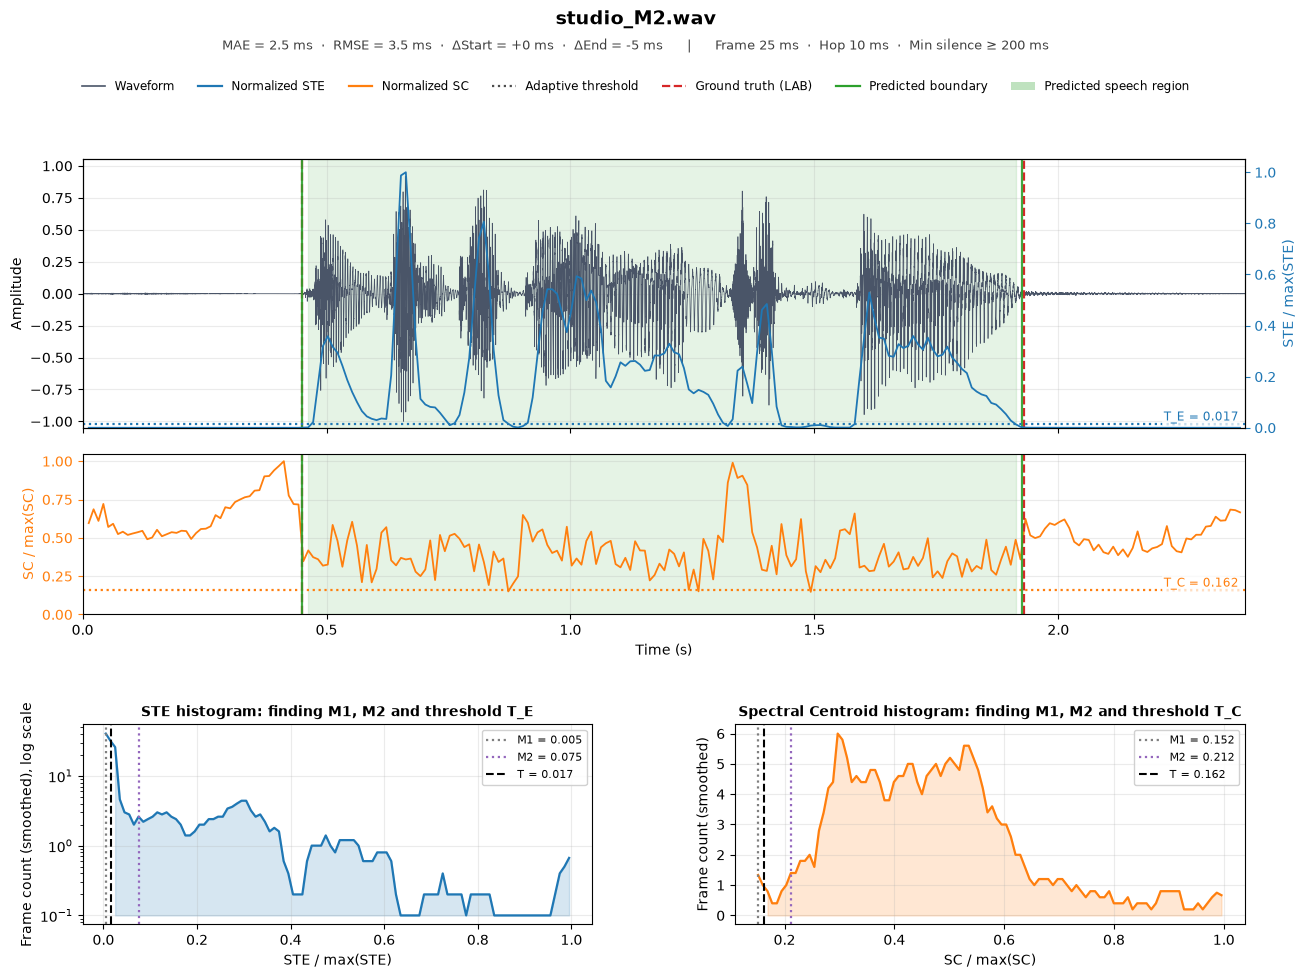

🎵 Original Audio (studio_M2.wav):


🔊 Predicted Speech Segment [0.45s - 1.93s]:


In [16]:
plot_and_play_evaluation(test_eval_dict["studio_M2.wav"])

### 17. Khảo sát tinh chỉnh độ đệm biên (Boundary-Padding Sweep)
Khảo sát quét tham số đệm biên (0-4 khung) duy nhất trên tập huấn luyện TRAIN để tối ưu hóa MAE.

In [17]:
MAX_PAD = 4

sweep = []
for pad_start in range(MAX_PAD + 1):
    for pad_end in range(MAX_PAD + 1):
        candidate = HistogramVAD(pad_start=pad_start, pad_end=pad_end)
        sweep.append((mean_mae(evaluate(train_set, candidate)), pad_start, pad_end))
sweep.sort()

print(f"{'pad_start':<10} {'pad_end':<8} {'Train MAE (ms)':>14}")
print("-" * 34)
for train_mae, pad_start, pad_end in sweep[:8]:
    print(f"{pad_start:<10} {pad_end:<8} {train_mae:>14.2f}")
print("\nTop configurations often tie (1 frame = 10 ms); on a tie, pick the simplest (symmetric, smallest).")

pad_start  pad_end  Train MAE (ms)
----------------------------------
1          0                 11.25
1          1                 11.25
2          0                 11.25
2          1                 11.25
0          0                 13.75
0          1                 13.75
3          1                 13.75
3          0                 13.75

Top configurations often tie (1 frame = 10 ms); on a tie, pick the simplest (symmetric, smallest).
